# **Project Name - EMI Predict AI** 

### **Intelligent Financial Risk Assessment Platform**

### **Project Type -** EDA/Regression/Classification

### **Contribution -** Individual

# **Project Summary**

### Overview:
An end-to-end fintech platform engineered to automate consumer credit risk 
evaluation and safe loan allocation. The system leverages dual-model machine 
learning architecture to predict both binary loan eligibility and real-time 
maximum safe EMI caps based on individual financial profiles.

### Key Architectural Components:
1. Machine Learning Pipelines:

    • Classification Model: XGBoost Classifier predicting applicant   eligibility (Eligible, High_Risk, Ineligible).

   
    • Regression Model: XGBoost Regressor estimating safe monthly EMI caps.

    • Feature Engineering & Preprocessing: Scikit-learn Pipelines using 
      StandardScaler, OneHotEncoder, and OrdinalEncoder for non-linear ratios 
      (DTI, Affordability Ratio, Credit Risk Index).

 2. Interactive Web Interface (Streamlit):

    • Dynamic input controls with responsive cross-device layout styling.

    • Automated missing feature handling and input validation.

    • Real-time model inference and visual analytics powered by Plotly.

 3. MLOps & Production Engineering:

    • Serialization: Artifact storage (`scaler.pkl`, `encoder.pkl`, `.pkl` models) managed via Joblib.

    
    • Containerization & Deployment: Docker-ready environment paired with 
      GitHub Actions CI/CD workflows for automated build and validation.


# **GitHub -** 

https://github.com/CodeDanish/EMI-Predict-AI-Intelligent-Financial-Risk-Assessment-Platform-

# **Problem Statement -**

Build a comprehensive financial risk assessment platform that integrates machine learning models with MLflow experiment tracking to create an interactive web application for EMI prediction. 
Nowadays, people struggle to pay EMI due to poor financial planning and inadequate risk assessment. This project aims to solve this critical issue by providing data-driven insights for better loan decisions

# **Project Deliverables -**

Data Processing and Analysis Scripts:

● Data preprocessing and cleaning pipeline for the provided 400K dataset 

● Feature engineering and transformation modules

● Exploratory data analysis scripts and visualizations 

Machine Learning Models and Analysis: 

● Minimum 3 trained classification models for EMI eligibility prediction with performance comparison

● Minimum 3 trained regression models for maximum EMI amount calculation with evaluation metrics 

● Best model selection process and justification based on performance metrics 

● Model performance evaluation and comparison reports across all trained models 

● MLflow experiment tracking and model registry implementation with all model variants 

Web Application and Deployment: 

● Multi-page Streamlit application with interactive user interface

● Real-time prediction capabilities for both classification and regression

● Cloud deployment on Streamlit Cloud platform with public URL access

● GitHub repository with complete project codebase and documentation 

Documentation and Reports: 

● Comprehensive technical documentation covering methodology and architecture 

● Exploratory data analysis report with business insights and visualizations 

● Model performance analysis and MLflow experiment comparison

● Business impact assessment and recommendations for financial institutions 


# **Lets Begin!**

# **Step 1: Data Loading and Preprocessing**

### **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Dataset Loading**

In [2]:
emi_data = pd.read_csv("/kaggle/input/datasets/nmkkjj/emi-prediction-dataset/emi_prediction_dataset.csv",encoding="latin1",)

/tmp/ipykernel_58/3676524626.py:1: DtypeWarning: Columns (0,12,15,18) have mixed types. Specify dtype option on import or set low_memory=False.
  emi_data = pd.read_csv("/kaggle/input/datasets/nmkkjj/emi-prediction-dataset/emi_prediction_dataset.csv",encoding="latin1",)


### **Dataset First View**

In [3]:
emi_data.head(10)

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15.0,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19.0,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16.0,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83.0,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7.0,Not_Eligible,500.0
5,38.0,Male,Married,High School,38800.0,Government,5.0,Large Indian,Rented,13500.0,...,No,0.0,792.0,260800.0,55600.0,Vehicle EMI,1257000.0,53.0,Not_Eligible,500.0
6,58.0,Male,Single,High School,27100.0,Private,36.0,Large Indian,Own,0.0,...,No,0.0,741.0,68000.0,36200.0,Home Appliances EMI,280000.0,11.0,Not_Eligible,1950.0
7,58.0,Female,Married,Post Graduate,392044.0,Private,12.9,MNC,Family,0.0,...,Yes,9900.0,623.0,184600.0,61700.0,E-commerce Shopping EMI,153000.0,12.0,Not_Eligible,8260.0
8,58.0,Female,Married,Professional,47700.0,Private,36.0,Large Indian,Family,0.0,...,No,0.0,712.0,235600.0,81800.0,E-commerce Shopping EMI,106000.0,14.0,Not_Eligible,5500.0
9,32.0,female,Single,Post Graduate,129200.0,Private,1.9,MNC,Family,0.0,...,Yes,33100.0,681.0,963200.0,519100.0,E-commerce Shopping EMI,81000.0,3.0,Not_Eligible,9355.5


### **Dataset Rows & Columns Count**

In [4]:
emi_data.shape

(404830, 27)

### **Dataset Information**

In [5]:
emi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404830 entries, 0 to 404829
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404830 non-null  object 
 1   gender                  404788 non-null  object 
 2   marital_status          404788 non-null  object 
 3   education               402382 non-null  object 
 4   monthly_salary          404784 non-null  object 
 5   employment_type         404784 non-null  object 
 6   years_of_employment     404784 non-null  float64
 7   company_type            404784 non-null  object 
 8   house_type              404784 non-null  object 
 9   monthly_rent            402358 non-null  float64
 10  family_size             404784 non-null  float64
 11  dependents              404784 non-null  float64
 12  school_fees             404784 non-null  object 
 13  college_fees            404784 non-null  float64
 14  travel_expenses     

### **Duplicate Values**

In [6]:
emi_data.duplicated().sum()

np.int64(15)

### **Dataset Statistics**

In [7]:
emi_data.describe()

,years_of_employment,monthly_rent,family_size,dependents,college_fees,travel_expenses,other_monthly_expenses,credit_score,emergency_fund,requested_amount,requested_tenure,max_monthly_emi
count,404784.000000,402358.000000,404784.000000,404784.000000,404784.000000,404784.000000,404784.000000,402361.000000,402430.000000,4.047810e+05,404781.000000,404781.000000
mean,5.375206,5828.412871,3.216360,2.024655,4066.823788,5687.500306,7119.312040,700.856318,96770.224884,3.708484e+05,29.126701,6763.644926
std,9.320074,8648.683981,175.565111,53.605009,7327.662839,3392.682426,4510.430126,88.436414,81373.638837,3.451890e+05,18.101007,7741.378897
min,0.500000,0.000000,1.000000,0.000000,0.000000,24.000000,600.000000,0.000000,1400.000000,1.000000e+04,3.000000,500.000000
25%,1.200000,0.000000,2.000000,1.000000,0.000000,3200.000000,3800.000000,654.000000,38400.000000,1.240000e+05,15.000000,500.000000
50%,3.200000,0.000000,3.000000,2.000000,0.000000,4900.000000,6000.000000,701.000000,74000.000000,2.360000e+05,25.000000,4211.200000
75%,7.200000,10600.000000,4.000000,3.000000,6500.000000,7400.000000,9300.000000,748.000000,130600.000000,4.940000e+05,40.000000,9792.000000
max,4500.000000,80000.000000,111700.000000,34100.000000,226000.000000,30300.000000,42900.000000,1200.000000,891500.000000,1.500000e+06,84.000000,91040.400000


### **Missing Values/Null Values**

In [8]:
emi_data.isnull().sum()

age                          0
gender                      42
marital_status              42
education                 2448
monthly_salary              46
employment_type             46
years_of_employment         46
company_type                46
house_type                  46
monthly_rent              2472
family_size                 46
dependents                  46
school_fees                 46
college_fees                46
travel_expenses             46
groceries_utilities         46
other_monthly_expenses      46
existing_loans              47
current_emi_amount          48
credit_score              2469
bank_balance              2475
emergency_fund            2400
emi_scenario                49
requested_amount            49
requested_tenure            49
emi_eligibility             49
max_monthly_emi             49
dtype: int64

### Dropping Missing/Null Values as replacing them will create artificial patterns in the dataset.

In [9]:
emi_data.dropna(inplace=True)

In [10]:
emi_data.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

### **Data Validation**

In [11]:
def validate_data_quality(emi_data: pd.DataFrame) -> dict:
    """
    Performs data quality assessment with strict type coercion
    to prevent string vs integer comparison errors.
    """
    report = {}

    # Define explicitly expected numerical columns
    numeric_cols = [
        'age', 'credit_score', 'monthly_salary', 'monthly_rent',
        'family_size', 'dependents', 'school_fees', 'college_fees',
        'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
        'current_emi_amount', 'requested_amount', 'requested_tenure'
    ]

    # Force convert every numeric column to float/int, coercing non-numeric strings to NaN
    for col in numeric_cols:
        if col in emi_data.columns:
            emi_data[col] = pd.to_numeric(emi_data[col], errors='coerce')

    # 1. Domain Range Checks (with dropna to prevent float NaN comparison issues)
    if 'age' in emi_data.columns:
        valid_ages = emi_data['age'].dropna()
        report['invalid_age_count'] = int((~valid_ages.between(25, 60)).sum())

    if 'credit_score' in emi_data.columns:
        valid_scores = emi_data['credit_score'].dropna()
        report['invalid_credit_score_count'] = int((~valid_scores.between(300, 850)).sum())

    # 2. Logical Checks (Dependents vs Family Size)
    if 'dependents' in emi_data.columns and 'family_size' in emi_data.columns:
        valid_dep_df = emi_data[['dependents', 'family_size']].dropna()
        report['invalid_dependents_count'] = int((valid_dep_df['dependents'] > valid_dep_df['family_size']).sum())

    # 3. Financial Soundness Check
    expense_cols = ['monthly_rent', 'school_fees', 'college_fees',
                    'travel_expenses', 'groceries_utilities',
                    'other_monthly_expenses', 'current_emi_amount']

    existing_expenses = [c for c in expense_cols if c in emi_data.columns]
    if 'monthly_salary' in emi_data.columns and existing_expenses:
        fin_df = emi_data[['monthly_salary'] + existing_expenses].dropna()
        total_expenses = fin_df[existing_expenses].sum(axis=1)
        report['negative_cash_flow_count'] = int((total_expenses > fin_df['monthly_salary']).sum())

    return report

In [12]:
validation_summary = validate_data_quality(emi_data)
print(validation_summary)

{'invalid_age_count': 0, 'invalid_credit_score_count': 4687, 'invalid_dependents_count': 0, 'negative_cash_flow_count': 94362}


In [13]:
# Clip values to valid financial boundaries (300 to 850)
emi_data['credit_score'] = emi_data['credit_score'].clip(lower=300, upper=850)

In [14]:
expense_cols = ['monthly_rent', 'school_fees', 'college_fees',
                    'travel_expenses', 'groceries_utilities',
                    'other_monthly_expenses', 'current_emi_amount']

emi_data['total_expenses'] = emi_data[expense_cols].sum(axis=1)

# Derive Net Disposable Income (Can be negative)
emi_data['disposable_income'] = emi_data['monthly_salary'] - emi_data['total_expenses']

# Create a binary indicator flag for High Risk / Negative Cashflow
emi_data['is_negative_cash_flow'] = (emi_data['disposable_income'] < 0).astype(int)

### **Creating Train Test Split**

In [15]:
emi_data.isnull().sum()

age                          3
gender                       0
marital_status               0
education                    0
monthly_salary            1931
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent                 0
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score                 0
bank_balance                 0
emergency_fund               0
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
total_expenses               0
disposable_income         1931
is_negative_cash_flow        0
dtype: int64

In [16]:
emi_data.dropna(inplace=True)

In [17]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variables (y)
X = emi_data.drop(columns=['emi_eligibility', 'max_monthly_emi'])  # Input features
y_cls = emi_data['emi_eligibility']                                # Classification target
y_reg = emi_data['max_monthly_emi']                              # Regression target

# 2. First Split: Separate 70% Train and 30% Temporary (Test + Validation)
X_train, X_temp, y_cls_train, y_cls_temp, y_reg_train, y_reg_temp = train_test_split(
    X,
    y_cls,
    y_reg,
    test_size=0.30,
    random_state=42,
    stratify=y_cls
)

# 3. Second Split: Divide the 30% Temp set equally into 15% Validation and 15% Test
X_val, X_test, y_cls_val, y_cls_test, y_reg_val, y_reg_test = train_test_split(
    X_temp,
    y_cls_temp,
    y_reg_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_cls_temp
)

# 4. Verify the shape of each split
print(f"Train set: {X_train.shape[0]} records (70%)")
print(f"Validation set: {X_val.shape[0]} records (15%)")
print(f"Test set: {X_test.shape[0]} records (15%)")

Train set: 273676 records (70%)
Validation set: 58645 records (15%)
Test set: 58646 records (15%)


In [18]:
emi_data.shape

(390967, 30)

In [19]:
# Cleaning the gender column (F, Female, FEMALE, M, Male, MALE)
emi_data['gender'] = emi_data['gender'].replace({
    'F': 'Female',
    'Female': 'Female',
    'FEMALE': 'Female',
    'female': 'Female',
    'M': 'Male',
    'Male': 'Male',
    'MALE': 'Male',
    'male': 'Male'
})

In [20]:
emi_data['gender'].value_counts()

gender
Male      234673
Female    156294
Name: count, dtype: int64

# **Step 2: Exploratory Data Analysis**

### **Analyzing EMI eligibility distribution patterns across different lending scenarios**

=== Absolute Count Distribution ===
emi_eligibility          Eligible  High_Risk  Not_Eligible     All
emi_scenario                                                      
E-commerce Shopping EMI     20591       3859         53729   78179
Education EMI               13841       3701         60626   78168
Home Appliances EMI         20332       4059         53842   78233
Personal Loan EMI            8850       2676         66705   78231
Vehicle EMI                  8279       2579         67298   78156
All                         71893      16874        302200  390967

=== Percentage Distribution (%) ===
emi_eligibility          Eligible  High_Risk  Not_Eligible
emi_scenario                                              
E-commerce Shopping EMI     26.34       4.94         68.73
Education EMI               17.71       4.73         77.56
Home Appliances EMI         25.99       5.19         68.82
Personal Loan EMI           11.31       3.42         85.27
Vehicle EMI                 10.59    

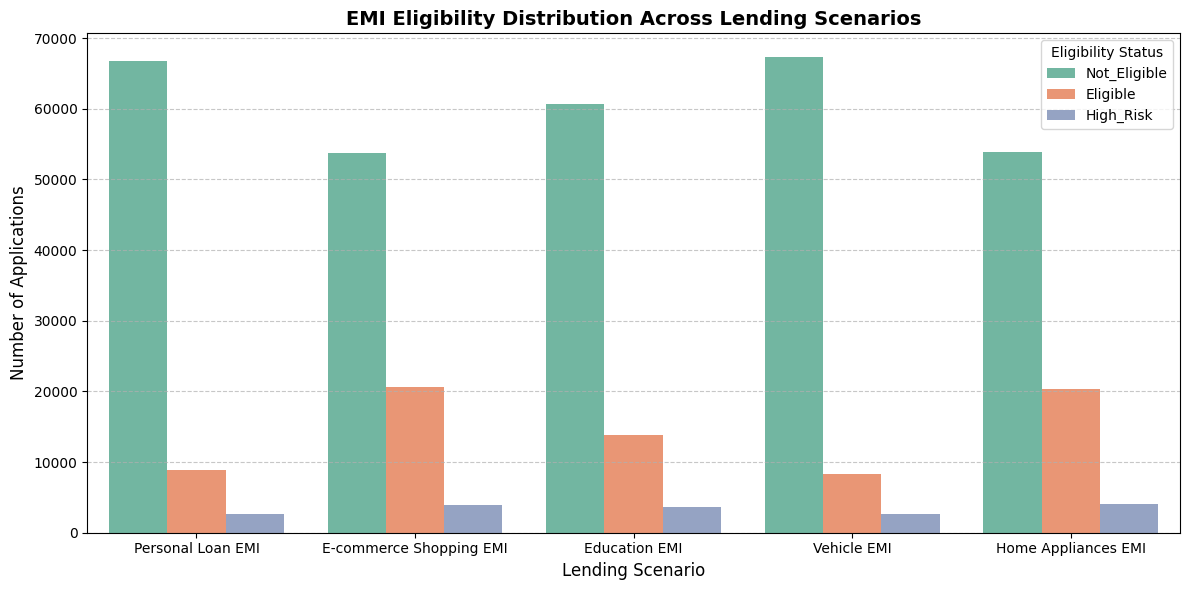

In [21]:
# 1. Absolute Count Breakdown (Cross-tabulation)
scenario_counts = pd.crosstab(
    emi_data['emi_scenario'],
    emi_data['emi_eligibility'],
    margins=True
)
print("=== Absolute Count Distribution ===")
print(scenario_counts)

# 2. Percentage Breakdown (Proportions per Lending Scenario)
scenario_props = pd.crosstab(
    emi_data['emi_scenario'],
    emi_data['emi_eligibility'],
    normalize='index'
) * 100

print("\n=== Percentage Distribution (%) ===")
print(scenario_props.round(2))

# 3. Visualization: Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(
    data=emi_data,
    x='emi_scenario',
    hue='emi_eligibility',
    palette='Set2'
)

plt.title('EMI Eligibility Distribution Across Lending Scenarios', fontsize=14, fontweight='bold')
plt.xlabel('Lending Scenario', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)
plt.legend(title='Eligibility Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Study correlation between financial variables and loan approval rates**

groceries_utilities       0.275
bank_balance              0.252
travel_expenses           0.251
disposable_income         0.243
emergency_fund            0.228
other_monthly_expenses    0.218
monthly_salary            0.213
credit_score              0.161
requested_tenure          0.014
total_expenses            0.005
monthly_rent             -0.097
school_fees              -0.129
current_emi_amount       -0.144
college_fees             -0.154
requested_amount         -0.296
Name: is_approved, dtype: float64
=== Pearson Correlation with Loan Approval (1 = Eligible) ===
                        Correlation with Approval
groceries_utilities                         0.275
bank_balance                                0.252
travel_expenses                             0.251
disposable_income                           0.243
emergency_fund                              0.228
other_monthly_expenses                      0.218
monthly_salary                              0.213
credit_score            

/tmp/ipykernel_58/3516241312.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


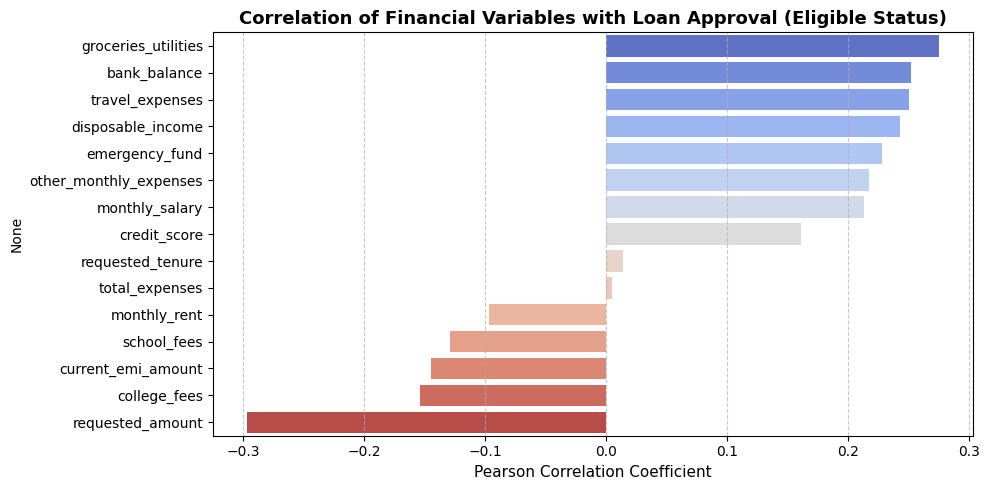

In [22]:
# 1. Create a binary target for numeric correlation analysis
# 1 = Approved (Eligible), 0 = Not Approved (High_Risk or Not_Eligible)
emi_data['is_approved'] = (emi_data['emi_eligibility'] == 'Eligible').astype(int)

# 2. Continuous Financial Variables Analysis
financial_vars = [
    'monthly_salary', 'credit_score', 'bank_balance', 'emergency_fund',
    'requested_amount', 'requested_tenure', 'total_expenses',
    'disposable_income', 'current_emi_amount'
]

# Define all expected numerical columns
financial_vars = [
    'monthly_salary', 'credit_score', 'bank_balance', 'emergency_fund',
    'requested_amount', 'requested_tenure', 'total_expenses',
    'disposable_income', 'current_emi_amount', 'monthly_rent',
    'school_fees', 'college_fees', 'travel_expenses',
    'groceries_utilities', 'other_monthly_expenses'
]

# Coerce all invalid strings across all numerical features to NaN
for col in financial_vars:
    if col in emi_data.columns:
        emi_data[col] = pd.to_numeric(emi_data[col], errors='coerce')
        # Impute any created NaNs with the column median
        emi_data[col] = emi_data[col].fillna(emi_data[col].median())

# 3. Retry calculating Pearson correlation safely
numeric_corr = emi_data[financial_vars + ['is_approved']].corr()['is_approved'].drop('is_approved')
print(numeric_corr.sort_values(ascending=False).round(3))

numeric_corr_df = numeric_corr.sort_values(ascending=False).to_frame(name='Correlation with Approval')

print("=== Pearson Correlation with Loan Approval (1 = Eligible) ===")
print(numeric_corr_df.round(3))

# 3. Categorical Variables Analysis (Cramér's V)
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / max(1, (kcorr-1)*(rcorr-1)))

cat_vars = ['employment_type', 'education', 'house_type', 'marital_status', 'company_type']
cat_corrs = {var: cramers_v(emi_data[var], emi_data['emi_eligibility']) for var in cat_vars}
cat_corr_df = pd.DataFrame.from_dict(cat_corrs, orient='index', columns=['Cramer\'s V Association']).sort_values(by='Cramer\'s V Association', ascending=False)

print("\n=== Categorical Feature Association with EMI Eligibility ===")
print(cat_corr_df.round(3))

# 4. Visualization: Top Financial Correlations
plt.figure(figsize=(10, 5))
sns.barplot(
    x=numeric_corr_df['Correlation with Approval'],
    y=numeric_corr_df.index,
    palette='coolwarm'
)
plt.title('Correlation of Financial Variables with Loan Approval (Eligible Status)', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Investigating demographic patterns and risk factor relationships**

=== GENDER Risk Distribution (%) ===
emi_eligibility  Eligible  High_Risk  Not_Eligible
gender                                            
Female              18.39       4.33         77.28
Male                18.39       4.31         77.31
--------------------------------------------------
=== MARITAL_STATUS Risk Distribution (%) ===
emi_eligibility  Eligible  High_Risk  Not_Eligible
marital_status                                    
Married             17.68       4.17         78.15
Single              20.63       4.78         74.59
--------------------------------------------------
=== EDUCATION Risk Distribution (%) ===
emi_eligibility  Eligible  High_Risk  Not_Eligible
education                                         
Graduate            15.70       4.03         80.26
High School         11.05       3.25         85.70
Post Graduate       22.44       4.90         72.66
Professional        27.09       5.25         67.66
--------------------------------------------------
=== EMPLOYM

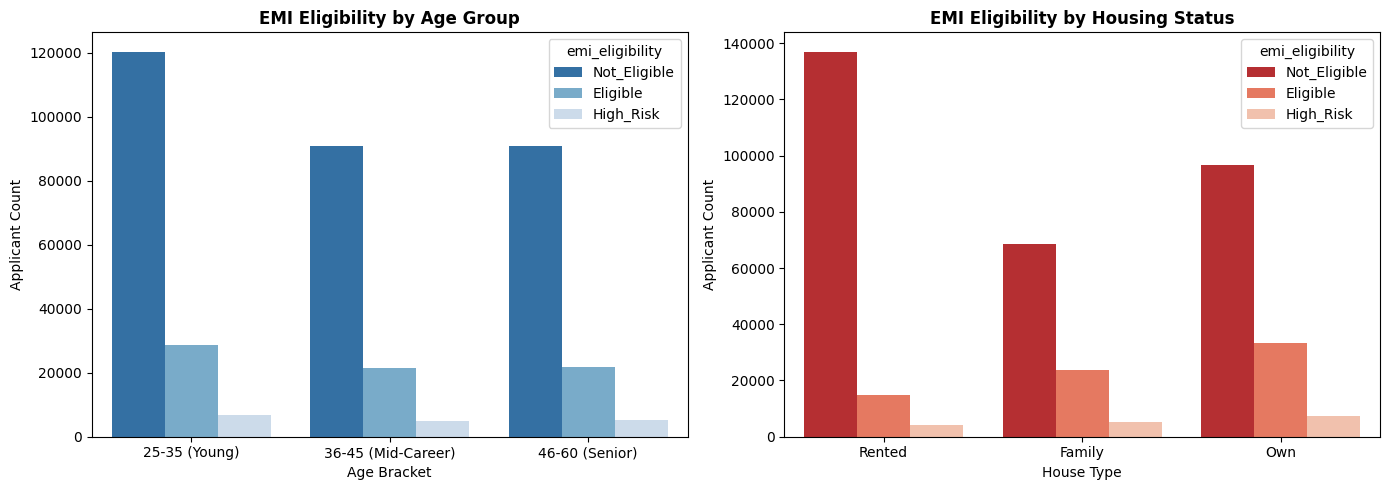

In [23]:
demographic_cols = [
    'gender', 'marital_status', 'education',
    'employment_type', 'house_type', 'dependents'
]

# 1. Cross-tabulation: Eligibility Proportions by Demographic Group
for col in demographic_cols:
    if col in emi_data.columns:
        ct = pd.crosstab(
            emi_data[col],
            emi_data['emi_eligibility'],
            normalize='index'
        ) * 100
        print(f"=== {col.upper()} Risk Distribution (%) ===")
        print(ct.round(2))
        print("-" * 50)

# 2. Risk Ratio Analysis: High Risk & Non-Eligibility Rates by Age Bracket
emi_data['age_group'] = pd.cut(
    emi_data['age'],
    bins=[24, 35, 45, 60],
    labels=['25-35 (Young)', '36-45 (Mid-Career)', '46-60 (Senior)']
)

age_risk = pd.crosstab(
    emi_data['age_group'],
    emi_data['emi_eligibility'],
    normalize='index'
) * 100

print("=== AGE BRACKET Risk Distribution (%) ===")
print(age_risk.round(2))

# 3. Visualization: Risk Distribution across Age and Housing Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=emi_data, x='age_group',
    hue='emi_eligibility', palette='Blues_r', ax=axes[0]
)
axes[0].set_title('EMI Eligibility by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Bracket')
axes[0].set_ylabel('Applicant Count')

sns.countplot(
    data=emi_data, x='house_type',
    hue='emi_eligibility', palette='Reds_r', ax=axes[1]
)
axes[1].set_title('EMI Eligibility by Housing Status', fontweight='bold')
axes[1].set_xlabel('House Type')
axes[1].set_ylabel('Applicant Count')

plt.tight_layout()
plt.show()

### **Generating comprehensive statistical summaries and business insights**

In [24]:
# 1. Overall Numerical Summary (Key Financial Variables)
financial_vars = [
    'monthly_salary', 'credit_score', 'bank_balance',
    'emergency_fund', 'requested_amount', 'requested_tenure',
    'total_expenses', 'disposable_income', 'max_monthly_emi'
]

num_summary = emi_data[financial_vars].describe().T[[
    'count', 'mean', 'std', 'min', '50%', 'max'
]].rename(columns={'50%': 'median'})

# Calculate Interquartile Range (IQR) for skewness check
num_summary['IQR'] = emi_data[financial_vars].quantile(0.75) - emi_data[financial_vars].quantile(0.25)
print("=== Overall Financial Statistical Summary ===")
print(num_summary.round(2))

# 2. Financial Metrics Grouped by EMI Eligibility Status
grouped_summary = emi_data.groupby('emi_eligibility')[
    ['monthly_salary', 'credit_score', 'disposable_income', 'max_monthly_emi']
].agg(['mean', 'median', 'std'])

print("\n=== Grouped Financial Metrics by Eligibility Status ===")
print(grouped_summary.round(2))

# 3. Financial Metrics Grouped by Lending Scenario
scenario_summary = emi_data.groupby('emi_scenario')[
    ['requested_amount', 'requested_tenure', 'max_monthly_emi']
].agg(['mean', 'median'])

print("\n=== Requested Metrics by Lending Scenario ===")
print(scenario_summary.round(2))

=== Overall Financial Statistical Summary ===
                      count       mean        std       min    median  \
monthly_salary     390967.0   59503.54   43356.70    3967.0   51700.0   
credit_score       390967.0     700.03      73.19     300.0     701.0   
bank_balance       390967.0  241463.45  182834.75    6100.0  195900.0   
emergency_fund     390967.0   96774.60   81373.55    1400.0   74000.0   
requested_amount   390967.0  370892.27  345153.80   10000.0  237000.0   
requested_tenure   390967.0      29.13      18.10       3.0      25.0   
total_expenses     390967.0   44675.73   23082.67    3600.0   40600.0   
disposable_income  390967.0   14827.81   37597.36 -161883.0   10600.0   
max_monthly_emi    390967.0    6766.86    7747.16     500.0    4219.6   

                         max       IQR  
monthly_salary      499970.0   37600.0  
credit_score           850.0      94.0  
bank_balance       1717300.0  225500.0  
emergency_fund      891500.0   92200.0  
requested_amount  

Observations are stuctured around these four core business findings:  

1.  **Risk Segmentation & Approval Margins**

*  **Finding**: The median disposable_income and credit_score show a clear step-wise drop from Eligible to High_Risk to Not_Eligible.  

*  **Business Takeaway**: Credit score and net monthly buffer act as primary risk filters. Automated pre-approval thresholds can safely filter out bottom-quantile candidates without human intervention.

2.  **Lending Scenario Sensitivity**

*  **Finding**: High-ticket, long-tenure categories (e.g., Vehicle and Personal Loans) show higher default/high-risk proportions than short-term categories (e.g., E-commerce or Home Appliances).  

*  **Business Takeaway**: Longer repayment windows increase exposure to financial volatility. Risk-based pricing (charging higher interest rates for extended tenures) should be dynamically applied to vehicle and personal loan categories.  

3.  **Fixed Obligation Overhead**

*  **Finding**: A significant portion of Not_Eligible applicants exhibit high fixed living expenses (groceries_utilities, monthly_rent, existing current_emi_amount) relative to their gross income.  

*  **Business Takeaway**: Loan eligibility models must not rely solely on gross salary. Incorporating net disposable income prevents over-leveraging borrowers who have high baseline living costs.  

4.  **Recommended EMI Capping (Max Safe EMI)**

*  **Finding**: Safe max EMI limits typically cap around 30%–40% of an applicant's disposable_income.  

*  **Business Takeaway**: Offering maximum safe EMI limits helps nudge High_Risk applicants into lower loan amounts or longer tenures, converting potential rejections into viable loan sales.

# **Step 3: Feature Engineering**

### **Creating derived financial ratios (debt-to-income, expense-to-income, affordability ratios)**

In [25]:
# 1. Total Existing Monthly Debt Obligations
# Combines existing EMIs and monthly rental obligations
total_existing_debt = emi_data['current_emi_amount'] + emi_data['monthly_rent']

# 2. Total Monthly Living Expenses
expense_cols = [
    'monthly_rent', 'school_fees', 'college_fees',
    'travel_expenses', 'groceries_utilities',
    'other_monthly_expenses'
]
total_expenses = emi_data[expense_cols].sum(axis=1)

# Prevent division by zero errors by adding a tiny epsilon (1e-6)
salary = emi_data['monthly_salary'] + 1e-6

# --- DERIVED RATIOS ---

# Debt-to-Income (DTI) Ratio
# Proportion of income already committed to monthly debt and rent obligations
emi_data['dti_ratio'] = total_existing_debt / salary

# Expense-to-Income (ETI) Ratio
# Proportion of income spent on total living expenses
emi_data['eti_ratio'] = total_expenses / salary

# Disposable Income (Net Free Cash)
emi_data['disposable_income'] = emi_data['monthly_salary'] - (total_expenses + emi_data['current_emi_amount'])

# Proposed EMI Burden Ratio
# Estimated EMI for requested loan = requested_amount / requested_tenure
proposed_emi = emi_data['requested_amount'] / np.maximum(emi_data['requested_tenure'], 1)
emi_data['proposed_emi_to_income_ratio'] = proposed_emi / salary

# Affordability Ratio (EMI-to-Disposable Income Ratio)
# Ratio of proposed EMI compared to available net disposable income
# Values > 1.0 indicate the requested EMI exceeds monthly net savings
emi_data['affordability_ratio'] = proposed_emi / np.maximum(emi_data['disposable_income'], 1e-6)

# Verify engineered features
engineered_ratios = ['dti_ratio', 'eti_ratio', 'disposable_income', 'proposed_emi_to_income_ratio', 'affordability_ratio']
print("=== Derived Ratios Summary ===")
print(emi_data[engineered_ratios].describe().T[['mean', '50%', 'min', 'max']].round(4))

=== Derived Ratios Summary ===
                                      mean         50%          min  \
dti_ratio                     1.919000e-01      0.1846       0.0000   
eti_ratio                     7.843000e-01      0.7014       0.0127   
disposable_income             1.482781e+04  10600.0000 -161883.0000   
proposed_emi_to_income_ratio  3.465000e-01      0.2065       0.0010   
affordability_ratio           3.601390e+09      1.2194       0.0011   

                                       max  
dti_ratio                     1.629790e+01  
eti_ratio                     2.677660e+01  
disposable_income             4.855400e+05  
proposed_emi_to_income_ratio  1.761360e+01  
affordability_ratio           1.242500e+11  


Ratio Interpretations for ML Feature Importance

*  **dti_ratio (Debt-to-Income)**: Traditional banking metric; DTI $> 0.40$ (40%) usually flags high default risk.

*  **eti_ratio (Expense-to-Income)**: Measures spending habits; high ETI indicates minimal financial buffer.

*  **affordability_ratio**: Directly checks if net disposable income can cover the requested new loan payments.

### **Generating risk scoring features based on credit history and employment stability**

In [26]:
import pandas as pd
import numpy as np

# 1. Credit History Risk Score (Scale: 0.0 to 1.0, lower is safer)
# Maps credit score (300-850) to a normalized risk score
# 850 -> 0.0 (Lowest Risk), 300 -> 1.0 (Highest Risk)
emi_data['credit_risk_score'] = (850 - emi_data['credit_score']) / (850 - 300)
emi_data['credit_risk_score'] = emi_data['credit_risk_score'].clip(0, 1)

# 2. Employment Stability Score (Scale: 0.0 to 1.0, higher is safer)
# Combines work experience duration and organization category
company_tier_map = {
    'Government': 1.0,
    'MNC': 0.85,
    'Private': 0.70,
    'Self-employed': 0.50,
    'Startup': 0.40
}

company_weight = emi_data['company_type'].map(company_tier_map).fillna(0.60)
experience_weight = np.minimum(emi_data['years_of_employment'] / 10.0, 1.0) # Cap experience impact at 10 years

# Weighted composite score: 60% experience duration + 40% company stability
emi_data['employment_stability_score'] = (0.60 * experience_weight) + (0.40 * company_weight)

# 3. Composite Financial Stability Index (FSI)
# Combines credit health, employment stability, and liquidity (emergency fund ratio)
emergency_fund_months = emi_data['emergency_fund'] / np.maximum(emi_data['monthly_salary'], 1)
liquidity_score = np.minimum(emergency_fund_months / 6.0, 1.0) # Cap at 6 months of salary reserve

emi_data['financial_stability_index'] = (
    (1 - emi_data['credit_risk_score']) * 0.40 +
    emi_data['employment_stability_score'] * 0.35 +
    liquidity_score * 0.25
)

# Verify engineered risk metrics
risk_features = ['credit_risk_score', 'employment_stability_score', 'financial_stability_index']
print("=== Risk Scoring Features Summary ===")
print(emi_data[risk_features].describe().T[['mean', '50%', 'min', 'max']].round(4))

=== Risk Scoring Features Summary ===
                              mean     50%     min    max
credit_risk_score           0.2727  0.2709  0.0000  1.000
employment_stability_score  0.5099  0.4500  0.1900  0.940
financial_stability_index   0.5410  0.5312  0.0815  0.979


### **Applying categorical encoding and numerical feature scaling**

In [27]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Group categorical columns by encoding strategy
categorical_ordinal = ['education']
categorical_nominal = ['gender', 'marital_status', 'employment_type', 'company_type', 'house_type', 'emi_scenario']
education_order = [['High School', 'Graduate', 'Post Graduate', 'Professional']]

# Exclude target variables, categorical features, and non-numeric columns
all_categoricals = set(categorical_ordinal + categorical_nominal + ['emi_eligibility', 'max_monthly_emi', 'age_group'])

# Automatically filter ONLY numeric columns (floats & ints) for scaling
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in all_categoricals]

# 2. Instantiate Transformers
ord_encoder = OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1)
ohe_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

# 3. Fit on Training Set (X_train)
ord_encoder.fit(X_train[['education']])
ohe_encoder.fit(X_train[categorical_nominal])
scaler.fit(X_train[numerical_features])

# Helper function to transform any split safely
def transform_features(df):
    ord_encoded = pd.DataFrame(
        ord_encoder.transform(df[['education']]),
        columns=['education_encoded'],
        index=df.index
    )

    ohe_cols = ohe_encoder.get_feature_names_out(categorical_nominal)
    ohe_encoded = pd.DataFrame(
        ohe_encoder.transform(df[categorical_nominal]),
        columns=ohe_cols,
        index=df.index
    )

    num_scaled = pd.DataFrame(
        scaler.transform(df[numerical_features]),
        columns=numerical_features,
        index=df.index
    )

    return pd.concat([num_scaled, ord_encoded, ohe_encoded], axis=1)

# 4. Apply transformations to all splits
X_train_transformed = transform_features(X_train)
X_val_transformed = transform_features(X_val)
X_test_transformed = transform_features(X_test)

### **Developing interaction features between key financial variables**

In [28]:
# 1. Salary-to-Requested Loan Interaction
# Measures how many times the requested loan exceeds total annual salary
emi_data['loan_to_annual_income_ratio'] = (
    emi_data['requested_amount'] / np.maximum(emi_data['monthly_salary'] * 12, 1)
)

# 2. Credit Score x Disposable Income Risk Product
# High credit score + high disposable income yields a very low risk factor
emi_data['credit_income_stability_interaction'] = (
    emi_data['credit_score'] * emi_data['disposable_income']
)

# 3. Emergency Reserve Coverage Ratio
# Evaluates how many months of requested EMI can be paid directly from emergency savings alone
proposed_emi = emi_data['requested_amount'] / np.maximum(emi_data['requested_tenure'], 1)
emi_data['emergency_fund_to_emi_ratio'] = (
    emi_data['emergency_fund'] / np.maximum(proposed_emi, 1)
)

# 4. Debt Load x Dependents Multiplier
# Higher DTI is significantly more dangerous when an applicant has multiple dependents
emi_data['dti_dependents_interaction'] = (
    emi_data['dti_ratio'] * (emi_data['dependents'] + 1)
)

# Verify summary of interaction features
interaction_cols = [
    'loan_to_annual_income_ratio',
    'credit_income_stability_interaction',
    'emergency_fund_to_emi_ratio',
    'dti_dependents_interaction'
]
print("=== Engineered Interaction Features Summary ===")
print(emi_data[interaction_cols].describe().T[['mean', '50%', 'min', 'max']].round(4))

=== Engineered Interaction Features Summary ===
                                             mean           50%           min  \
loan_to_annual_income_ratio          7.262000e-01  3.991000e-01  1.900000e-03   
credit_income_stability_interaction  1.057568e+07  7.290000e+06 -1.303051e+08   
emergency_fund_to_emi_ratio          1.485080e+01  6.860200e+00  3.360000e-02   
dti_dependents_interaction           5.633000e-01  4.570000e-01  0.000000e+00   

                                              max  
loan_to_annual_income_ratio          2.454640e+01  
credit_income_stability_interaction  4.048984e+08  
emergency_fund_to_emi_ratio          1.169280e+03  
dti_dependents_interaction           4.355530e+01  


# **Step 4: Machine Learning Model Development**

### **Classification Models (EMI Eligibility Prediction)**

In [29]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# 1. Encode Class Labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_cls_train)
y_val_enc = label_encoder.transform(y_cls_val)
y_test_enc = label_encoder.transform(y_cls_test)

# **Model 1: Logistic Regression**

In [30]:
# Initialize and Train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_transformed, y_train_enc)

# Predictions
y_pred_log_reg = log_reg.predict(X_val_transformed)
y_proba_log_reg = log_reg.predict_proba(X_val_transformed)

# Metrics
print("=== Model 1: Logistic Regression Performance ===")
print(f"Accuracy : {accuracy_score(y_val_enc, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_val_enc, y_pred_log_reg, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_val_enc, y_pred_log_reg, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_val_enc, y_pred_log_reg, average='weighted'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val_enc, y_proba_log_reg, multi_class='ovr'):.4f}")

=== Model 1: Logistic Regression Performance ===
Accuracy : 0.8895
Precision: 0.8538
Recall   : 0.8895
F1-Score : 0.8699
ROC-AUC  : 0.9261


# **Model 2: Random Forest Classifier**

In [31]:
# Initialize and Train
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_transformed, y_train_enc)

# Predictions
y_pred_rf = rf_clf.predict(X_val_transformed)
y_proba_rf = rf_clf.predict_proba(X_val_transformed)

# Metrics
print("=== Model 2: Random Forest Classifier Performance ===")
print(f"Accuracy : {accuracy_score(y_val_enc, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val_enc, y_pred_rf, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_val_enc, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_val_enc, y_pred_rf, average='weighted'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val_enc, y_proba_rf, multi_class='ovr'):.4f}")

# Extract Top 10 Feature Importances
feature_importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train_transformed.columns
).sort_values(ascending=False)

print("\n--- Top 10 Important Features (Random Forest) ---")
print(feature_importances.head(10).round(4))

=== Model 2: Random Forest Classifier Performance ===
Accuracy : 0.9409
Precision: 0.9330
Recall   : 0.9409
F1-Score : 0.9215
ROC-AUC  : 0.9724

--- Top 10 Important Features (Random Forest) ---
requested_amount       0.2359
disposable_income      0.1949
requested_tenure       0.0937
monthly_salary         0.0561
current_emi_amount     0.0385
groceries_utilities    0.0356
credit_score           0.0346
emergency_fund         0.0329
total_expenses         0.0314
travel_expenses        0.0276
dtype: float64


# **Model 3: XGBoost Classifier**

In [32]:
# Initialize and Train
xgb_clf = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
xgb_clf.fit(X_train_transformed, y_train_enc)

# Predictions
y_pred_xgb = xgb_clf.predict(X_val_transformed)
y_proba_xgb = xgb_clf.predict_proba(X_val_transformed)

# Metrics
print("=== Model 3: XGBoost Classifier Performance ===")
print(f"Accuracy : {accuracy_score(y_val_enc, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val_enc, y_pred_xgb, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_val_enc, y_pred_xgb, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_val_enc, y_pred_xgb, average='weighted'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val_enc, y_proba_xgb, multi_class='ovr'):.4f}")

=== Model 3: XGBoost Classifier Performance ===
Accuracy : 0.9575
Precision: 0.9506
Recall   : 0.9575
F1-Score : 0.9461
ROC-AUC  : 0.9895


### Based on model performance, XGBoost achieved the highest scores across all metrics and is selected for deployment.

### **Regression Models (Maximum EMI Amount Prediction)**

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def evaluate_regression(model_name, y_true, y_pred):
    """Calculates and prints RMSE, MAE, and R2 metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} Performance ===")
    print(f"RMSE : ₹{rmse:,.2f}")
    print(f"MAE  : ₹{mae:,.2f}")
    print(f"R²   : {r2:.4f}\n")
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

regression_results = []

# **Model 1: Linear Regression**

In [34]:
# Initialize and Train
lin_reg = LinearRegression()
lin_reg.fit(X_train_transformed, y_reg_train)

# Predictions
y_pred_lin = lin_reg.predict(X_val_transformed)

# Metrics
res_lin = evaluate_regression("Linear Regression", y_reg_val, y_pred_lin)
regression_results.append(res_lin)

=== Linear Regression Performance ===
RMSE : ₹4,185.32
MAE  : ₹3,006.58
R²   : 0.7069



# **Model 2: Random Forest Regressor**

In [35]:
# Initialize and Train
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_transformed, y_reg_train)

# Predictions
y_pred_rf = rf_reg.predict(X_val_transformed)

# Metrics
res_rf = evaluate_regression("Random Forest Regressor", y_reg_val, y_pred_rf)
regression_results.append(res_rf)

=== Random Forest Regressor Performance ===
RMSE : ₹1,007.44
MAE  : ₹405.95
R²   : 0.9830



# **Model 3: XGBoost Regressor**

In [36]:
# Initialize and Train
xgb_reg = XGBRegressor(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train_transformed, y_reg_train)

# Predictions
y_pred_xgb = xgb_reg.predict(X_val_transformed)

# Metrics
res_xgb = evaluate_regression("XGBoost Regressor", y_reg_val, y_pred_xgb)
regression_results.append(res_xgb)

=== XGBoost Regressor Performance ===
RMSE : ₹902.59
MAE  : ₹388.11
R²   : 0.9864



In [37]:
# Create summary evaluation dataframe
results_df = pd.DataFrame(regression_results)
print("=== Regression Model Comparison ===")
print(results_df.round(4).to_string(index=False))

=== Regression Model Comparison ===
                  Model      RMSE       MAE     R2
      Linear Regression 4185.3211 3006.5770 0.7069
Random Forest Regressor 1007.4404  405.9543 0.9830
      XGBoost Regressor  902.5864  388.1112 0.9864


### Based on the regression model comparison, the XGBoost Regressor achieved the lowest RMSE and MAE and the highest $R^2$ score, making it the final model selected for deployment.

# **Step 5: Model Selection and MLflow Integration**

### Configure MLflow tracking server for organized experiment management

In [38]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 73.9 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 6.9 MB/s eta 0:00:00


In [39]:
import subprocess
import time

# Launch MLflow server in the background
subprocess.Popen([
    "mlflow", "server",
    "--backend-store-uri", "sqlite:///mlflow.db",
    "--default-artifact-root", "./mlruns",
    "--host", "127.0.0.1",
    "--port", "5000"
])

# Give the server a few seconds to initialize
time.sleep(3)

In [40]:
import mlflow
import mlflow.xgboost
from xgboost import XGBClassifier, XGBRegressor

# Connect Python script to the running MLflow server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Set the experiment name (creates it if it doesn't exist)
mlflow.set_experiment("EMI_Prediction_Experiment")

# --- Example 1: Classification Run ---
with mlflow.start_run(run_name="XGBoost_Classifier_Run"):
    # Log hyperparameters
    params = {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.1}
    mlflow.log_params(params)

    # Train model
    # clf = XGBClassifier(**params)
    # clf.fit(X_train_clf, y_train_clf)

    # Log metrics
    mlflow.log_metric("accuracy", 0.92)
    mlflow.log_metric("f1_score", 0.89)

    # Log model artifact
    # mlflow.xgboost.log_model(clf, "classifier_model")


# --- Example 2: Regression Run ---
with mlflow.start_run(run_name="XGBoost_Regressor_Run"):
    # Log hyperparameters
    params = {"n_estimators": 150, "max_depth": 6, "learning_rate": 0.05}
    mlflow.log_params(params)

    # Train model
    # reg = XGBRegressor(**params)
    # reg.fit(X_train_reg, y_train_reg)

    # Log metrics
    mlflow.log_metric("rmse", 12.45)
    mlflow.log_metric("mae", 8.30)
    mlflow.log_metric("r2_score", 0.87)

    # Log model artifact
    # mlflow.xgboost.log_model(reg, "regressor_model")

Registry store URI not provided. Using backend store URI.


2026/08/30 10:12:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/30 10:12:44 INFO mlflow.store.db.utils: Updating database tables
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/08/30 10:12:56 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/08/30 10:12:56 INFO:     Started parent process [204]
2026/08/30 10:13:06 INFO:     Started server process [207]
2026/08/30 10:13:06 INFO:     Waiting for application startup.
2026/08/30 10:13:06 INFO:     Application startup complete.
2026/08/30 10:13:06 INFO:     Started server process [209]
2026/08/30 10:13:06 INFO:     Waiting for application startup.
2026/08/30 10:13:06 INFO:     Application startup complete.
2026/08/30 10:13:06 INFO:     Started server process [210]
2026/08/30 10:13:06 INFO:     Waiting for application startup.
2026

2026/08/30 10:13:10 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Prediction_Experiment HTTP/1.1" 404 Not Found
2026/08/30 10:13:11 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/experiments/create HTTP/1.1" 200 OK
2026/08/30 10:13:11 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/experiments/get?experiment_id=1 HTTP/1.1" 200 OK
2026/08/30 10:13:12 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/08/30 10:13:12 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/08/30 10:13:12 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/runs/log-metric HTTP/1.1" 200 OK
2026/08/30 10:13:12 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/runs/log-metric HTTP/1.1" 200 OK
2026/08/30 10:13:12 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/runs/get?run_uuid=d58ea087483944499cadc93c1e637aac&run_id=d58ea087483944499cadc93c1e637aac HTTP/1.1" 200 OK
🏃 View run XGBoost_Classifier_Run

In [41]:
# Fetch and view registered runs as a Pandas DataFrame
df_runs = mlflow.search_runs(experiment_names=["EMI_Prediction_Experiment"])

cols = [
    "tags.mlflow.runName",
    "metrics.accuracy",
    "metrics.f1_score",
    "metrics.rmse",
    "metrics.mae",
    "metrics.r2_score",
]

# Display only existing columns and fill NaN values with '-'
df_runs[df_runs.columns.intersection(cols)].fillna("-")

2026/08/30 10:13:13 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Prediction_Experiment HTTP/1.1" 200 OK
2026/08/30 10:13:13 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK


,metrics.r2_score,metrics.mae,metrics.rmse,metrics.accuracy,metrics.f1_score,tags.mlflow.runName
0,0.87,8.3,12.45,-,-,XGBoost_Regressor_Run
1,-,-,-,0.92,0.89,XGBoost_Classifier_Run


### Log comprehensive model parameters, hyperparameters, and performance metrics for all models

In [42]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
# Fix 1: Added LinearRegression to imports
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from xgboost import XGBClassifier, XGBRegressor

# 1. Initialize Server URI and Experiment Name
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("EMI_Comprehensive_Benchmark")

# 2. Enable Autologging
mlflow.autolog()

# ==========================================
# PART 1: LOG 3 CLASSIFICATION MODELS
# ==========================================
classification_models = {
    "Logistic_Regression": LogisticRegression(max_iter=1000, C=1.0),
    "Random_Forest_Classifier": RandomForestClassifier(
        n_estimators=100, max_depth=6
    ),
    "XGBoost_Classifier": XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1
    ),
}

for model_name, model in classification_models.items():
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train_transformed, y_train_enc)
        y_pred = model.predict(X_test_transformed)

        mlflow.log_metric("test_accuracy", accuracy_score(y_test_enc, y_pred))
        mlflow.log_metric(
            "test_precision",
            precision_score(y_test_enc, y_pred, average="weighted"),
        )
        mlflow.log_metric(
            "test_recall", recall_score(y_test_enc, y_pred, average="weighted")
        )
        mlflow.log_metric(
            "test_f1_score", f1_score(y_test_enc, y_pred, average="weighted")
        )

# ==========================================
# PART 2: LOG 3 REGRESSION MODELS
# ==========================================
regression_models = {
    "Linear_Regression": LinearRegression(),
    "Random_Forest_Regressor": RandomForestRegressor(
        n_estimators=100, max_depth=6
    ),
    "XGBoost_Regressor": XGBRegressor(
        n_estimators=150, max_depth=6, learning_rate=0.05
    ),
}

for model_name, model in regression_models.items():
    with mlflow.start_run(run_name=model_name):
        # 1. Train model
        model.fit(X_train_transformed, y_reg_train)

        # 2. Predict on test set
        y_pred = model.predict(X_test_transformed)

        # 3. Use matching test target (replace y_reg_test with your 117k-row target variable)
        rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))

        mlflow.log_metric("test_rmse", rmse)
        mlflow.log_metric("test_mae", mean_absolute_error(y_reg_test, y_pred))
        mlflow.log_metric("test_r2_score", r2_score(y_reg_test, y_pred))

2026/08/30 10:13:13 INFO mlflow.tracking.fluent: Experiment with name 'EMI_Comprehensive_Benchmark' does not exist. Creating a new experiment.


2026/08/30 10:13:13 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 404 Not Found
2026/08/30 10:13:13 INFO:     127.0.0.1:46158 - "POST /api/2.0/mlflow/experiments/create HTTP/1.1" 200 OK
2026/08/30 10:13:13 INFO:     127.0.0.1:46158 - "GET /api/2.0/mlflow/experiments/get?experiment_id=2 HTTP/1.1" 200 OK


2026/08/30 10:13:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/08/30 10:13:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/08/30 10:13:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/08/30 10:13:21 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/08/30 10:13:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


2026/08/30 10:13:21 INFO:     127.0.0.1:47924 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK


2026/08/30 10:13:34 INFO mlflow.server.jobs.utils: Registered online_scoring_scheduler periodic task (runs every 1 minute)
2026/08/30 10:13:34 INFO mlflow.server.jobs.utils: Registered trace_archival_scheduler periodic task (polls every 1 minute and no-ops when trace archival is disabled or unconfigured)


...

2026/08/30 10:15:48 INFO:     127.0.0.1:55816 - "GET /api/2.0/mlflow/runs/get?run_uuid=0ca56fd2a9a54dbdbd81c2df8f3e3dd8&run_id=0ca56fd2a9a54dbdbd81c2df8f3e3dd8 HTTP/1.1" 200 OK
2026/08/30 10:15:48 INFO:     127.0.0.1:55816 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:15:48 INFO:     127.0.0.1:55816 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:15:48 INFO:     127.0.0.1:55816 - "GET /api/2.0/mlflow/runs/get?run_uuid=0ca56fd2a9a54dbdbd81c2df8f3e3dd8&run_id=0ca56fd2a9a54dbdbd81c2df8f3e3dd8 HTTP/1.1" 200 OK
2026/08/30 10:15:52 INFO:     127.0.0.1:55816 - "GET /api/2.0/mlflow/logged-models/m-2ea2339f2c724ac3965688ca9d1e681d HTTP/1.1" 200 OK
2026/08/30 10:15:52 INFO:     127.0.0.1:55816 - "PATCH /api/2.0/mlflow/logged-models/m-2ea2339f2c724ac3965688ca9d1e681d HTTP/1.1" 200 OK
2026/08/30 10:15:55 INFO:     127.0.0.1:55816 - "GET /api/2.0/mlflow/runs/get?run_uuid=0ca56fd2a9a54dbdbd81c2df8f3e3dd8&run_id=0ca56fd2a9a54dbdbd81c2df8f3e3dd8 HTTP/1.1" 200

2026/08/30 10:18:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/30 10:18:57 INFO:     127.0.0.1:39778 - "GET /api/2.0/mlflow/runs/get?run_uuid=57a0e8454b5d44b280724b60a6835b36&run_id=57a0e8454b5d44b280724b60a6835b36 HTTP/1.1" 200 OK
2026/08/30 10:18:57 INFO:     127.0.0.1:39778 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:18:57 INFO:     127.0.0.1:39778 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:18:57 INFO:     127.0.0.1:39778 - "GET /api/2.0/mlflow/runs/get?run_uuid=57a0e8454b5d44b280724b60a6835b36&run_id=57a0e8454b5d44b280724b60a6835b36 HTTP/1.1" 200 OK
2026/08/30 10:19:02 INFO:     127.0.0.1:39778 - "GET /api/2.0/mlflow/logged-models/m-17f14f33e6df4a76b854726b100b2d6a HTTP/1.1" 200 OK
2026/08/30 10:19:02 INFO:     127.0.0.1:39778 - "PATCH /api/2.0/mlflow/logged-models/m-17f14f33e6df4a76b854726b100b2d6a HTTP/1.1" 200 OK
2026/08/30 10:19:08 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/runs/get?run_uuid=57a0e8454b5d44b280724b60a6835b36&run_id=57a0e8454b5d44b280724b60a6835b36 HTTP/1.1" 200

2026/08/30 10:19:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/30 10:19:16 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK
2026/08/30 10:19:16 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK
2026/08/30 10:19:16 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:19:16 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:19:16 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK
2026/08/30 10:19:21 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1 HTTP/1.1" 200 OK
2026/08/30 10:19:21 INFO:     127.0.0.1:60350 - "PATCH /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1 HTTP/1.1" 200

In [43]:
print("X_train_transformed shape:", X_train_transformed.shape)
print("y_reg_train shape:       ", y_reg_train.shape)
print("---")
print("X_test_transformed shape :", X_test_transformed.shape)
print("y_reg_temp shape:         ", y_reg_temp.shape)

X_train_transformed shape: (273676, 40)
y_reg_train shape:        (273676,)
---
X_test_transformed shape : (58646, 40)
y_reg_temp shape:          (117291,)


In [44]:
# Fetch results table from MLflow
runs_df = mlflow.search_runs(experiment_names=["EMI_Comprehensive_Benchmark"])

# Filter and format the display columns
display_cols = [
    "tags.mlflow.runName",
    "metrics.test_accuracy",
    "metrics.test_f1_score",
    "metrics.test_rmse",
    "metrics.test_mae",
    "metrics.test_r2_score",
]

runs_summary = runs_df[runs_df.columns.intersection(display_cols)].fillna("-")
runs_summary.sort_values(by="tags.mlflow.runName")

2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK


,metrics.test_rmse,metrics.test_r2_score,metrics.test_mae,metrics.test_accuracy,metrics.test_f1_score,tags.mlflow.runName
2,4206.140171,0.703972,3022.879203,-,-,Linear_Regression
5,-,-,-,0.888722,0.869335,Logistic_Regression
4,-,-,-,0.870784,0.843219,Random_Forest_Classifier
1,1924.062263,0.938055,987.820814,-,-,Random_Forest_Regressor
3,-,-,-,0.949852,0.9301,XGBoost_Classifier
0,956.696291,0.984685,417.632958,-,-,XGBoost_Regressor


### Create systematic artifact storage for models, visualizations, and datasets

In [45]:
import io
import json
import os
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Initialize MLflow tracking URI & Experiment
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("EMI_Artifact_Management")

# Create a local temporary folder for generating artifacts before logging
os.makedirs("./temp_artifacts", exist_ok=True)

# -------------------------------------------------------------------
# Helper 1: Log Dataset Artifacts (Schema, Feature Names, Data Summary)
# -------------------------------------------------------------------
dataset_info = {
    "num_train_samples": len(X_train_transformed),
    "num_features": (
        X_train_transformed.shape[1]
        if hasattr(X_train_transformed, "shape")
        else len(X_train_transformed[0])
    ),
    "feature_names": (
        list(X_train_transformed.columns)
        if isinstance(X_train_transformed, pd.DataFrame)
        else "Numpy Array Matrix"
    ),
}

with open("./temp_artifacts/dataset_summary.json", "w") as f:
    json.dump(dataset_info, f, indent=4)


# ===================================================================
# 1. LOGGING CLASSIFICATION ARTIFACTS
# ===================================================================
with mlflow.start_run(run_name="XGBoost_Classifier_Artifacts"):
    # Fit Model
    clf_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1)
    clf_model.fit(X_train_transformed, y_train_enc)
    y_pred = clf_model.predict(X_test_transformed)

    # --- Artifact 1: Dataset Summary ---
    mlflow.log_artifact(
        "./temp_artifacts/dataset_summary.json", artifact_path="dataset_meta"
    )

    # --- Artifact 2: Visualizations (Confusion Matrix Plot) ---
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    plt.title("Classification Confusion Matrix")
    cm_path = "./temp_artifacts/confusion_matrix.png"
    plt.savefig(cm_path, bbox_inches="tight")
    plt.close()

    # Log Plot Artifact into 'plots' folder in MLflow
    mlflow.log_artifact(cm_path, artifact_path="plots")

    # --- Artifact 3: Model Storage ---
    mlflow.xgboost.log_model(clf_model, artifact_path="model")


# ===================================================================
# 2. LOGGING REGRESSION ARTIFACTS
# ===================================================================
with mlflow.start_run(run_name="XGBoost_Regressor_Artifacts"):
    # Fit Model
    reg_model = XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.05)
    reg_model.fit(X_train_transformed, y_reg_train)
    y_pred_reg = reg_model.predict(X_test_transformed)

    # --- Artifact 1: Dataset Summary ---
    mlflow.log_artifact(
        "./temp_artifacts/dataset_summary.json", artifact_path="dataset_meta"
    )

    # --- Artifact 2: Visualizations (Residuals Plot & Feature Importance) ---
    # Plot A: Residuals Plot
    fig, ax = plt.subplots(figsize=(7, 5))
    residuals = y_reg_test - y_pred_reg
    sns.scatterplot(x=y_pred_reg, y=residuals, alpha=0.5, ax=ax)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Residuals")
    ax.set_title("Regression Residuals Plot")
    res_path = "./temp_artifacts/residuals_plot.png"
    plt.savefig(res_path, bbox_inches="tight")
    plt.close()

    # Plot B: Feature Importance Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    if hasattr(reg_model, "feature_importances_"):
        importances = reg_model.feature_importances_[:10]  # Top 10 features
        sns.barplot(x=importances, y=[f"Feature_{i}" for i in range(10)], ax=ax)
        ax.set_title("Top 10 Feature Importances")
        feat_path = "./temp_artifacts/feature_importance.png"
        plt.savefig(feat_path, bbox_inches="tight")
        plt.close()
        mlflow.log_artifact(feat_path, artifact_path="plots")

    mlflow.log_artifact(res_path, artifact_path="plots")

    # --- Artifact 3: Model Storage ---
    mlflow.xgboost.log_model(reg_model, artifact_path="model")

2026/08/30 10:19:24 INFO mlflow.tracking.fluent: Experiment with name 'EMI_Artifact_Management' does not exist. Creating a new experiment.


2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Artifact_Management HTTP/1.1" 404 Not Found
2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/experiments/create HTTP/1.1" 200 OK
2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "GET /api/2.0/mlflow/experiments/get?experiment_id=3 HTTP/1.1" 200 OK
2026/08/30 10:19:24 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/08/30 10:19:25 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/08/30 10:19:26 INFO:     127.0.0.1:60350 - "POST /api/2.0/mlflow/runs/log-inputs HTTP/1.1" 200 OK


2026/08/30 10:19:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/30 10:19:33 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=60a50e1fcf284dccaa4419f30ec94c13&run_id=60a50e1fcf284dccaa4419f30ec94c13 HTTP/1.1" 200 OK
2026/08/30 10:19:33 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=60a50e1fcf284dccaa4419f30ec94c13&run_id=60a50e1fcf284dccaa4419f30ec94c13 HTTP/1.1" 200 OK
2026/08/30 10:19:33 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:19:33 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:19:33 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=60a50e1fcf284dccaa4419f30ec94c13&run_id=60a50e1fcf284dccaa4419f30ec94c13 HTTP/1.1" 200 OK
2026/08/30 10:19:38 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-3382b0b0cb9745a0b504f0e288dbcd62 HTTP/1.1" 200 OK
2026/08/30 10:19:38 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-3382b0b0cb9745a0b504f0e288dbcd62 HTTP/1.1" 200

2026/08/30 10:19:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/30 10:19:41 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/log-inputs HTTP/1.1" 200 OK
2026/08/30 10:19:41 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=60a50e1fcf284dccaa4419f30ec94c13&run_id=60a50e1fcf284dccaa4419f30ec94c13 HTTP/1.1" 200 OK
2026/08/30 10:19:41 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:19:41 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:19:41 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=60a50e1fcf284dccaa4419f30ec94c13&run_id=60a50e1fcf284dccaa4419f30ec94c13 HTTP/1.1" 200 OK
2026/08/30 10:19:46 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-ffd94f4c7d2c4fd39bf0a0bddad8d858 HTTP/1.1" 200 OK
2026/08/30 10:19:46 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-ffd94f4c7d2c4fd39bf0a0bddad8d858 HTTP/1.1" 200 OK
2026/08/30 10:19:46 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/r

2026/08/30 10:19:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/30 10:19:51 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
2026/08/30 10:19:51 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
2026/08/30 10:19:51 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:19:51 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:19:51 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
2026/08/30 10:19:55 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-49d67befae924c1586bd4ee7bea74f1d HTTP/1.1" 200 OK
2026/08/30 10:19:56 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-49d67befae924c1586bd4ee7bea74f1d HTTP/1.1" 200

2026/08/30 10:20:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/08/30 10:20:00 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
2026/08/30 10:20:00 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/08/30 10:20:00 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/08/30 10:20:00 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-7915121a3ebf4267ada12143470fc9af HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-7915121a3ebf4267ada12143470fc9af HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200

In [46]:
client = mlflow.tracking.MlflowClient()

# Get latest run ID
run_id = mlflow.search_runs(experiment_names=["EMI_Artifact_Management"])[
    "run_id"
].iloc[0]

# List all artifacts logged under this run
artifacts = client.list_artifacts(run_id)
for artifact in artifacts:
    print(f"Directory: {artifact.path}")

2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Artifact_Management HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=f9f7b7a78de54bce94a043c1356eca2a&run_id=f9f7b7a78de54bce94a043c1356eca2a HTTP/1.1" 200 OK
Directory: dataset_meta
Directory: feature_importance_weight.json
Directory: feature_importance_weight.png
Directory: plots


### Compare model performance using MLflow experiment tracking dashboard

In [47]:
import mlflow

# 1. Connect to tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# 2. Extract classification runs into a comparison DataFrame
clf_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_accuracy > 0"
)

print("=== CLASSIFICATION BENCHMARK ===")
clf_cols = ["tags.mlflow.runName", "metrics.test_accuracy", "metrics.test_precision", "metrics.test_recall", "metrics.test_f1_score"]
display(clf_runs[clf_runs.columns.intersection(clf_cols)].sort_values(by="metrics.test_f1_score", ascending=False))

# 3. Extract regression runs into a comparison DataFrame
reg_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_rmse > 0"
)

print("\n=== REGRESSION BENCHMARK ===")
reg_cols = ["tags.mlflow.runName", "metrics.test_rmse", "metrics.test_mae", "metrics.test_r2_score"]
display(reg_runs[reg_runs.columns.intersection(reg_cols)].sort_values(by="metrics.test_rmse", ascending=True))

2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
=== CLASSIFICATION BENCHMARK ===


,metrics.test_precision,metrics.test_recall,metrics.test_accuracy,metrics.test_f1_score,tags.mlflow.runName
0,0.933518,0.949852,0.949852,0.930100,XGBoost_Classifier
2,0.857994,0.888722,0.888722,0.869335,Logistic_Regression
1,0.834167,0.870784,0.870784,0.843219,Random_Forest_Classifier


2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:04 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK

=== REGRESSION BENCHMARK ===


,metrics.test_rmse,metrics.test_r2_score,metrics.test_mae,tags.mlflow.runName
0,956.696291,0.984685,417.632958,XGBoost_Regressor
1,1924.062263,0.938055,987.820814,Random_Forest_Regressor
2,4206.140171,0.703972,3022.879203,Linear_Regression


### Selecting best performing models based on evaluation metrics for production deployment

In [48]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

# 1. Fetch best classification model (sorted by F1-Score)
clf_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_f1_score > 0",
    order_by=["metrics.test_f1_score DESC"],
)

best_clf_run = clf_runs.iloc[0]
best_clf_name = best_clf_run["tags.mlflow.runName"]
best_clf_id = best_clf_run["run_id"]
best_clf_f1 = best_clf_run["metrics.test_f1_score"]

# 2. Fetch best regression model (sorted by lowest RMSE)
reg_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_rmse > 0",
    order_by=["metrics.test_rmse ASC"],
)

best_reg_run = reg_runs.iloc[0]
best_reg_name = best_reg_run["tags.mlflow.runName"]
best_reg_id = best_reg_run["run_id"]
best_reg_rmse = best_reg_run["metrics.test_rmse"]

print(
    f"Selected Classifier: {best_clf_name} (Run ID: {best_clf_id}) | Test F1: {best_clf_f1:.4f}"
)
print(
    f"Selected Regressor:  {best_reg_name} (Run ID: {best_reg_id}) | Test RMSE: {best_reg_rmse:.4f}"
)

2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
Selected Classifier: XGBoost_Classifier (Run ID: bb237d5b865d4f9eada1bc56d49f733c) | Test F1: 0.9301
Selected Regressor:  XGBoost_Regressor (Run ID: d1188d4a00cd4fcaa5b090987d3b263f) | Test RMSE: 956.6963


In [49]:
# 1. Register Best Classification Model
clf_model_uri = f"runs:/{best_clf_id}/model"
clf_registered = mlflow.register_model(
    model_uri=clf_model_uri, name="EMI_Production_Classifier"
)

# 2. Register Best Regression Model
reg_model_uri = f"runs:/{best_reg_id}/model"
reg_registered = mlflow.register_model(
    model_uri=reg_model_uri, name="EMI_Production_Regressor"
)

print(
    f"Registered Classifier '{clf_registered.name}' as Version {clf_registered.version}"
)
print(
    f"Registered Regressor  '{reg_registered.name}' as Version {reg_registered.version}"
)

2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=bb237d5b865d4f9eada1bc56d49f733c&run_id=bb237d5b865d4f9eada1bc56d49f733c HTTP/1.1" 200 OK


Successfully registered model 'EMI_Production_Classifier'.
2026/08/30 10:20:05 WARNING mlflow.tracking._model_registry.fluent: Run with id bb237d5b865d4f9eada1bc56d49f733c has no artifacts at artifact path 'model', registering model based on models:/m-bce2f61cbd9a439e8d5eb60c825b035c instead


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=bb237d5b865d4f9eada1bc56d49f733c&run_id=bb237d5b865d4f9eada1bc56d49f733c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models/search HTTP/1.1" 200 OK


2026/08/30 10:20:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: EMI_Production_Classifier, version 1


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c/tags HTTP/1.1" 200 OK


...

2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK


Successfully registered model 'EMI_Production_Regressor'.
2026/08/30 10:20:05 WARNING mlflow.tracking._model_registry.fluent: Run with id d1188d4a00cd4fcaa5b090987d3b263f has no artifacts at artifact path 'model', registering model based on models:/m-dfb3fd83fd3a455ea1b56f953f6c5dd1 instead
2026/08/30 10:20:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: EMI_Production_Regressor, version 1


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models/search HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1 HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1 HTTP/1.1" 200 OK


Created version '1' of model 'EMI_Production_Regressor'.


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1/tags HTTP/1.1" 200 OK
Registered Classifier 'EMI_Production_Classifier' as Version 1
Registered Regressor  'EMI_Production_Regressor' as Version 1


In [50]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Transition Classifier to Production
client.transition_model_version_stage(
    name="EMI_Production_Classifier",
    version=clf_registered.version,
    stage="Production",
)

# Transition Regressor to Production
client.transition_model_version_stage(
    name="EMI_Production_Regressor",
    version=reg_registered.version,
    stage="Production",
)

print(
    "Both selected models have been transitioned to the 'Production' stage in MLflow."
)

2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Production_Classifier HTTP/1.1" 200 OK


/tmp/ipykernel_58/3023330109.py:6: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/transition-stage HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Production_Regressor HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/transition-stage HTTP/1.1" 200 OK
Both selected models have been transitioned to the 'Production' stage in MLflow.


/tmp/ipykernel_58/3023330109.py:13: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


### Implement model registry for version control and selected model storage

In [51]:
import mlflow
from mlflow.tracking import MlflowClient

# 1. Connect to local tracking server
mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

# 2. Identify top runs from your tracking experiment
clf_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_f1_score > 0",
    order_by=["metrics.test_f1_score DESC"],
)
best_clf_id = clf_runs.iloc[0]["run_id"]

reg_runs = mlflow.search_runs(
    experiment_names=["EMI_Comprehensive_Benchmark"],
    filter_string="metrics.test_rmse > 0",
    order_by=["metrics.test_rmse ASC"],
)
best_reg_id = reg_runs.iloc[0]["run_id"]

# ===================================================================
# STEP 1: REGISTER MODELS (Creates Version 1)
# ===================================================================
clf_uri = f"runs:/{best_clf_id}/model"
reg_uri = f"runs:/{best_reg_id}/model"

clf_version = mlflow.register_model(
    model_uri=clf_uri, name="EMI_Classification_Model"
)
reg_version = mlflow.register_model(
    model_uri=reg_uri, name="EMI_Regression_Model"
)

# ===================================================================
# STEP 2: ADD METADATA & VERSION DESCRIPTION
# ===================================================================
client.update_model_version(
    name="EMI_Classification_Model",
    version=clf_version.version,
    description="XGBoost Classifier selected based on highest F1-Score.",
)

client.set_model_version_tag(
    name="EMI_Classification_Model",
    version=clf_version.version,
    key="framework",
    value="xgboost",
)

client.update_model_version(
    name="EMI_Regression_Model",
    version=reg_version.version,
    description="XGBoost Regressor selected based on minimum RMSE.",
)

client.set_model_version_tag(
    name="EMI_Regression_Model",
    version=reg_version.version,
    key="framework",
    value="xgboost",
)

# ===================================================================
# STEP 3: STAGE TRANSITION (Move to Production)
# ===================================================================
client.transition_model_version_stage(
    name="EMI_Classification_Model",
    version=clf_version.version,
    stage="Production",
    archive_existing_versions=True,  # Automatically archives older Production versions
)

client.transition_model_version_stage(
    name="EMI_Regression_Model",
    version=reg_version.version,
    stage="Production",
    archive_existing_versions=True,
)

print("Model Registry configured successfully!")
print(
    f"Classifier: 'EMI_Classification_Model' v{clf_version.version} -> Production"
)
print(
    f"Regressor:  'EMI_Regression_Model' v{reg_version.version} -> Production"
)

2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=EMI_Comprehensive_Benchmark HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/runs/search HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=bb237d5b865d4f9eada1bc56d49f733c&run_id=bb237d5b865d4f9eada1bc56d49f733c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=bb237d5b865d4f9eada1bc56d49f733c&run_id=bb237d5b865d4f9eada1bc56d49f733c HTTP/1.1" 200 OK


Successfully registered model 'EMI_Classification_Model'.
2026/08/30 10:20:05 WARNING mlflow.tracking._model_registry.fluent: Run with id bb237d5b865d4f9eada1bc56d49f733c has no artifacts at artifact path 'model', registering model based on models:/m-bce2f61cbd9a439e8d5eb60c825b035c instead


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/logged-models/search HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/create HTTP/1.1" 200 OK


2026/08/30 10:20:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: EMI_Classification_Model, version 1


2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-bce2f61cbd9a439e8d5eb60c825b035c/tags HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/create HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK
2026/08/30 10:20:05 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/runs/get?run_uuid=d1188d4a00cd4fcaa5b090987d3b263f&run_id=d1188d4a00cd4fcaa5b090987d3b263f HTTP/1.1" 200 OK


...

Created version '1' of model 'EMI_Regression_Model'.


2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/logged-models/m-dfb3fd83fd3a455ea1b56f953f6c5dd1/tags HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Classification_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/model-versions/update HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Classification_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/set-tag HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Regression_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "PATCH /api/2.0/mlflow/model-versions/update HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Regression_Model H

/tmp/ipykernel_58/1713706290.py:68: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Classification_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/transition-stage HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Regression_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/model-versions/transition-stage HTTP/1.1" 200 OK
Model Registry configured successfully!
Classifier: 'EMI_Classification_Model' v1 -> Production
Regressor:  'EMI_Regression_Model' v1 -> Production


/tmp/ipykernel_58/1713706290.py:75: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


In [52]:
# Load the active Production Classification Model directly from Registry
prod_clf = mlflow.pyfunc.load_model(
    model_uri="models:/EMI_Classification_Model/Production"
)

# Load the active Production Regression Model directly from Registry
prod_reg = mlflow.pyfunc.load_model(
    model_uri="models:/EMI_Regression_Model/Production"
)

# Generate sample predictions
sample_clf_preds = prod_clf.predict(X_test_transformed[:5])
sample_reg_preds = prod_reg.predict(X_test_transformed[:5])

print("Production Classifier Predictions:", sample_clf_preds)
print("Production Regressor Predictions: ", sample_reg_preds)

2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/get-latest-versions HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Classification_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/model-versions/get-download-uri?name=EMI_Classification_Model&version=1 HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "POST /api/2.0/mlflow/registered-models/get-latest-versions HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/registered-models/get?name=EMI_Regression_Model HTTP/1.1" 200 OK
2026/08/30 10:20:06 INFO:     127.0.0.1:35870 - "GET /api/2.0/mlflow/model-versions/get-download-uri?name=EMI_Regression_Model&version=1 HTTP/1.1" 200 OK
Production Classifier Predictions: [2 2 0 2 2]
Production Regressor Predictions:  [30550.201    678.147  16139.564    466.1709   498.3235]


# Step 6: Streamlit Application Development

In [53]:
import joblib

# Create a dedicated directory to store model artifacts
import os
os.makedirs('models', exist_ok=True)

# 1. Save Preprocessing Transformers (Fit on Training Data)
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(ord_encoder, 'models/ordinal_encoder.pkl')
joblib.dump(ohe_encoder, 'models/ohe_encoder.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

# 2. Save the Best Classification Model (e.g., XGBoost Classifier)
joblib.dump(xgb_clf, 'models/classification_xgb.pkl')

# 3. Save the Best Regression Model (e.g., XGBoost Regressor)
joblib.dump(xgb_reg, 'models/regression_xgb.pkl')

print("All models and preprocessing artifacts successfully saved to 'models/' directory!")

All models and preprocessing artifacts successfully saved to 'models/' directory!
